X shape: (286, 1000)
y shape: (286,)
Accuracy: 0.7931034482758621


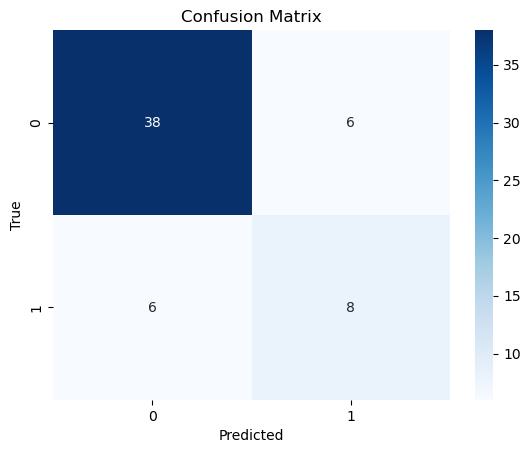

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        44
           1       0.57      0.57      0.57        14

    accuracy                           0.79        58
   macro avg       0.72      0.72      0.72        58
weighted avg       0.79      0.79      0.79        58



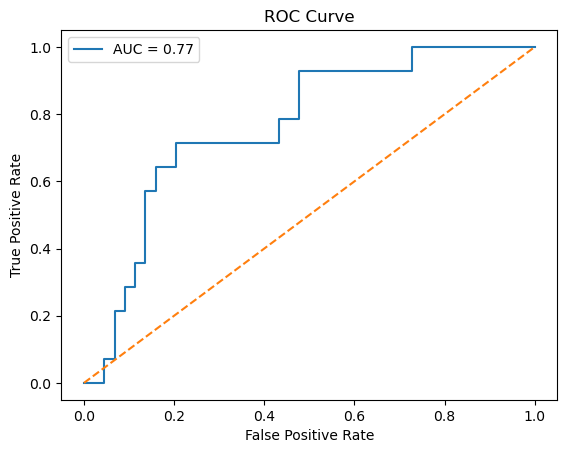

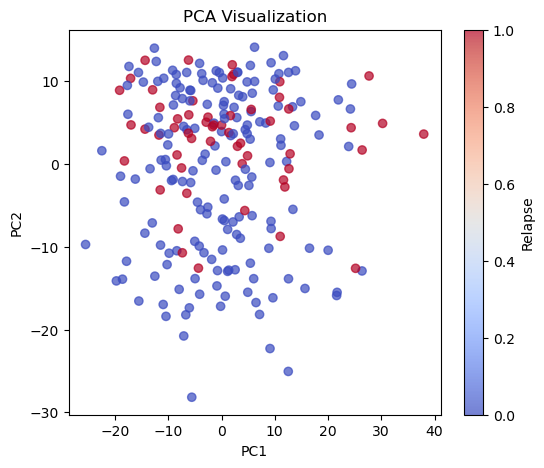

Top predictive genes:
205513_at      0.437244
209008_x_at    0.308004
213664_at      0.303002
214430_at      0.298753
207802_at      0.273022
208655_at      0.260324
202345_s_at    0.256650
202741_at      0.251700
205242_at      0.245730
204971_at      0.241774
208656_s_at    0.239937
200644_at      0.238268
201592_at      0.230814
208617_s_at    0.229513
39248_at       0.229205
202589_at      0.225574
217773_s_at    0.217742
209339_at      0.217034
200925_at      0.215682
205849_s_at    0.212175
dtype: float64
Annotation columns:
Index(['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date',
       'Sequence Type', 'Sequence Source', 'Target Description',
       'Representative Public ID', 'Gene Title', 'Gene Symbol',
       'ENTREZ_GENE_ID', 'RefSeq Transcript ID',
       'Gene Ontology Biological Process', 'Gene Ontology Cellular Component',
       'Gene Ontology Molecular Function'],
      dtype='object')
Mapping shape: (21225, 2)

Top Predictive Genes:
       Prob

In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

X = pd.read_csv("/mnt/c/Users/Surface/Desktop/Project1/GSE2034_reduced_expression.csv", index_col=0)
y = pd.read_csv("/mnt/c/Users/Surface/Desktop/Project1/GSE2034_labels.csv", index_col=0)

y = y.iloc[:, 0]

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap="coolwarm", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.colorbar(label="Relapse")
plt.show()

coefficients = pd.Series(
    model.coef_[0],
    index=X.columns
)

top_genes = coefficients.abs().sort_values(ascending=False).head(20)

print("Top predictive genes:")
print(top_genes)


# Below is Annotation file from GEO for GPL96 platform to map probe IDs to real gene symbols 

annot = pd.read_csv(
    "/mnt/c/Users/Surface/Desktop/Project1/GPL96-57554.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

print("Annotation columns:")
print(annot.columns)

probe_to_gene = annot[['ID', 'Gene Symbol']].copy()
probe_to_gene = probe_to_gene.dropna()
probe_to_gene = probe_to_gene[probe_to_gene['Gene Symbol'] != '---']

print("Mapping shape:", probe_to_gene.shape)


coefficients = pd.Series(
    model.coef_[0],
    index=X.columns
)

top_probes = coefficients.abs().sort_values(ascending=False).head(20)

top_df = top_probes.reset_index()
top_df.columns = ['Probe_ID', 'Importance']

top_df = top_df.merge(
    probe_to_gene,
    left_on='Probe_ID',
    right_on='ID',
    how='left'
)

top_df = top_df[['Probe_ID', 'Gene Symbol', 'Importance']]

print("\nTop Predictive Genes:")
print(top_df)